In [ ]:

import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, chi2_contingency

In [41]:
df = pd.read_csv('datasheet.csv')

In [ ]:
import matplotlib.pyplot as plt

def check_balance_bar(column_name):
    print(f"Distribution of '{column_name}':")
    counts = df[column_name].value_counts()
    print(counts)
    print("\nProportions:")
    proportions = counts / counts.sum()
    print(proportions)
    
    # bar chart
    plt.figure(figsize=(4, 3))
    plt.bar(counts.index.astype(str), counts.values, color=plt.cm.Paired.colors)
    plt.title(f"Distribution of '{column_name}'")
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example usage
check_balance_bar('Group')
check_balance_bar('Customer_Segment')
check_balance_bar('Purchase_Made')


In [43]:

def classify_columns(dataframe):
    column_info = {}
    for column in dataframe.columns:
        # Check data type
        dtype = dataframe[column].dtype
        # Classify column
        if pd.api.types.is_numeric_dtype(dataframe[column]):
            column_type = 'Numerical'
        elif pd.api.types.is_categorical_dtype(dataframe[column]) or dataframe[column].nunique() < 20:
            column_type = 'Categorical'
        else:
            column_type = 'Other'
        column_info[column] = column_type
    
    
    print("Column Classification:")
    for col, col_type in column_info.items():
        print(f"{col}: {col_type}")

classify_columns(df)

Column Classification:
Group: Categorical
Customer_Segment: Categorical
Sales_Before: Numerical
Sales_After: Numerical
Customer_Satisfaction_Before: Numerical
Customer_Satisfaction_After: Numerical
Purchase_Made: Categorical


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12924\3549335184.py:9: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or dataframe[column].nunique() < 20:


Analysis of Numerical Columns:

Statistics for Column: Sales_Before
Mean: 203.72
Median: 203.32
Variance: 3055.11
Standard Deviation: 55.27
----------------------------------------

Statistics for Column: Sales_After
Mean: 280.46
Median: 273.13
Variance: 7337.56
Standard Deviation: 85.66
----------------------------------------

Statistics for Column: Customer_Satisfaction_Before
Mean: 70.25
Median: 69.49
Variance: 287.54
Standard Deviation: 16.96
----------------------------------------

Statistics for Column: Customer_Satisfaction_After
Mean: 73.87
Median: 73.84
Variance: 328.64
Standard Deviation: 18.13
----------------------------------------


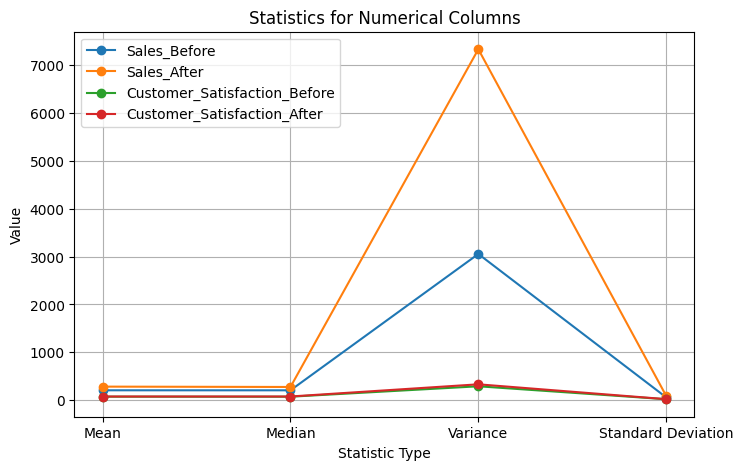

In [ ]:
def analyze_and_plot_numerical_columns(dataframe):
    print("Analysis of Numerical Columns:")
    
    # Create a figure for the plots
    plt.figure(figsize=(8, 5))

    for column in dataframe.columns:
        # Check if the column is numerical
        if pd.api.types.is_numeric_dtype(dataframe[column]):
            # Calculate statistics
            mean_val = dataframe[column].mean()
            median_val = dataframe[column].median()
            variance_val = dataframe[column].var()
            std_dev_val = dataframe[column].std()
            
            # Print statistics
            print(f"\nStatistics for Column: {column}")
            print(f"Mean: {mean_val:.2f}")
            print(f"Median: {median_val:.2f}")
            print(f"Variance: {variance_val:.2f}")
            print(f"Standard Deviation: {std_dev_val:.2f}")
            print("-" * 40)
            
            # Plot the statistics for the column
            plt.plot([1, 2, 3, 4], [mean_val, median_val, variance_val, std_dev_val], marker='o', label=column)
    
    # Set up plot
    plt.title("Statistics for Numerical Columns")
    plt.xlabel("Statistic Type")
    plt.ylabel("Value")
    plt.xticks([1, 2, 3, 4], ['Mean', 'Median', 'Variance', 'Standard Deviation'])
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

# Call the function
analyze_and_plot_numerical_columns(df)

In [66]:
import pandas as pd

# Count the number of missing (null) values in each column of the DataFrame
missing_counts = df.isnull().sum()

# Display the number of missing values for each column
print(missing_counts)


Name               1
Age                1
City               1
Purchase_Amount    1
dtype: int64


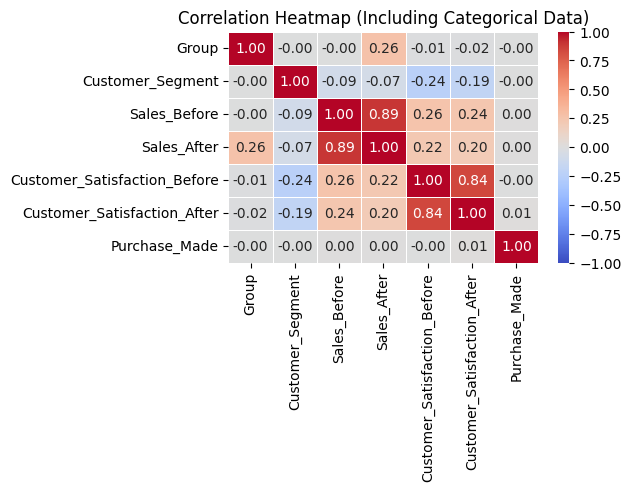

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

def encode_categorical_columns(dataframe):
    le = LabelEncoder()  # Initialize the label encoder
    categorical_columns = dataframe.select_dtypes(include=['object']).columns  # Identify categorical columns
    
    for column in categorical_columns:
        dataframe[column] = le.fit_transform(dataframe[column])  # Apply label encoding
    
    return dataframe


df_encoded = encode_categorical_columns(df)


def plot_correlation_heatmap(dataframe):
    corr_matrix = dataframe.corr()
    
    plt.figure(figsize=(5, 3))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

    plt.title("Correlation Heatmap (Including Categorical Data)")
    plt.show()


plot_correlation_heatmap(df_encoded)

In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv("datasheet.csv")

# Step 1: Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]  # Only columns with missing values

if missing.empty:
    print(" No missing values found in the dataset!")
else:
    print(" Missing values in each column:\n")
    print(missing)
    print("\nStarting to handle missing values...\n")

    # Step 2: Handle missing values based on data type
    for column in missing.index:
        if pd.api.types.is_numeric_dtype(df[column]):
            # Fill numeric column with its mean
            mean_value = df[column].mean()
            df[column].fillna(mean_value, inplace=True)
            print(f"✅ Filled missing values in numeric column '{column}' with mean: {mean_value:.2f}")
        else:
            # Fill categorical column with its mode
            mode_value = df[column].mode()[0]
            df[column].fillna(mode_value, inplace=True)
            print(f"✅ Filled missing values in categorical column '{column}' with mode: '{mode_value}'")

    print("\n🎉 All missing values have been handled successfully!")



🔍 Missing values in each column:

Group                           1401
Customer_Segment                1966
Sales_Before                    1522
Sales_After                      767
Customer_Satisfaction_Before    1670
Customer_Satisfaction_After     1640
Purchase_Made                    805
dtype: int64

Starting to handle missing values...

✅ Filled missing values in categorical column 'Group' with mode: 'Control'
✅ Filled missing values in categorical column 'Customer_Segment' with mode: 'Low Value'
✅ Filled missing values in numeric column 'Sales_Before' with mean: 203.72
✅ Filled missing values in numeric column 'Sales_After' with mean: 280.46
✅ Filled missing values in numeric column 'Customer_Satisfaction_Before' with mean: 70.25
✅ Filled missing values in numeric column 'Customer_Satisfaction_After' with mean: 73.87
✅ Filled missing values in categorical column 'Purchase_Made' with mode: 'Yes'

🎉 All missing values have been handled successfully!


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12924\499375725.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mode_value, inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12924\499375725.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [47]:


!pip install scikit-learn;

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB 1.4 MB/s eta 0:00:09
   ---------------------------------------- 0.1/11.1 MB 656.4 kB/s eta 0:00:17
   ---------------------------------------- 0.1/11.1 MB 804.6 kB/s eta 0:00:14
    --------------------------------------- 0.1/11.1 MB 853.3 kB/s eta 0:00:13
    --------------------------------------- 0.2/11.1 MB 706.2 kB/s eta 0:00:16
    --------------------------------------- 0.2/11.1 MB 655.4 kB/s eta 0:00:17
    --------------------------------------- 0.2/11.1 MB 655.9 kB/s eta 0:00:17
    --------------------------------------- 0.2/11.1 MB 655.9 kB/s eta 0:00:17
    --------------------------------------- 0.2/11.1 MB 655.9 kB/s eta 0:00:17
    --------------------------------------- 0.2/11.1 MB 655.9 kB/s eta 0:00:17
    --------------------------------------- 0.2/11.1 MB 655.9 kB/s eta 0:00:17
    --------------------------------------- 0.2/11.1 MB 366.4 k


[notice] A new release of pip is available: 24.0 -> 25.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
